### IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Plot settings
sns.set_theme(style="whitegrid")

### LOAD DATASET

df = pd.read_csv("LoanDataset.csv")4
df.head()

### DATASET OVERVIEW

In [5]:
print("Dataset Shape:")
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]:,}")

print("\n" + "="*50)
print("Column Names")
print("="*50)

print(df.columns.tolist())

print("\n" + "="*50)
print("Data Types")
print("="*50)

display(df.dtypes)

Dataset Shape:
Rows    : 32,586
Columns : 13

Column Names
['customer_id', 'customer_age', 'customer_income', 'home_ownership', 'employment_duration', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'term_years', 'historical_default', 'cred_hist_length', 'Current_loan_status']

Data Types


customer_id            float64
customer_age             int64
customer_income         object
home_ownership          object
employment_duration    float64
loan_intent             object
loan_grade              object
loan_amnt               object
loan_int_rate          float64
term_years               int64
historical_default      object
cred_hist_length         int64
Current_loan_status     object
dtype: object

### DUPLICATE RECORDS ANALYSIS

In [7]:
duplicate_count = df.duplicated().sum()

print("Duplicate Records:", duplicate_count)

if duplicate_count == 0:
    print("No duplicate records found.")
else:
    print(f"{duplicate_count:,} duplicate records found.")
    display(df[df.duplicated(keep=False)].head(10))

Duplicate Records: 6
6 duplicate records found.


,customer_id,customer_age,customer_income,home_ownership,employment_duration,loan_intent,loan_grade,loan_amnt,loan_int_rate,term_years,historical_default,cred_hist_length,Current_loan_status
322,323.0,25,120000,RENT,6.0,MEDICAL,A,"£1,000,000.00",10.74,10,N,2,DEFAULT
323,323.0,25,120000,RENT,6.0,MEDICAL,A,"£1,000,000.00",10.74,10,N,2,DEFAULT
324,324.0,23,120000,RENT,7.0,EDUCATION,A,"£25,000.00",9.99,10,NaN,2,NO DEFAULT
325,324.0,23,120000,RENT,7.0,EDUCATION,A,"£25,000.00",9.99,10,NaN,2,NO DEFAULT
14689,14688.0,21,32000,RENT,6.0,PERSONAL,B,"£15,000.00",15.27,1,Y,3,DEFAULT
14690,14689.0,22,38000,RENT,6.0,PERSONAL,A,"£15,000.00",7.88,2,N,3,DEFAULT
14691,14688.0,21,32000,RENT,6.0,PERSONAL,B,"£15,000.00",15.27,1,Y,3,DEFAULT
14692,14689.0,22,38000,RENT,6.0,PERSONAL,A,"£15,000.00",7.88,2,N,3,DEFAULT
30287,30284.0,47,70000,RENT,3.0,HOMEIMPROVEMENT,A,"£6,000.00",8.49,7,N,12,NO DEFAULT
30288,30285.0,44,70000,RENT,15.0,DEBTCONSOLIDATION,A,"£6,000.00",5.79,4,N,16,DEFAULT


### Statistical Summary

In [8]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
customer_id,32583.0,16289.497806,9405.919628,1.00,8144.5,16288.00,24433.50,32581.00
customer_age,32586.0,27.732769,6.360528,3.00,23.0,26.00,30.00,144.00
employment_duration,31691.0,4.790161,4.142746,0.00,2.0,4.00,7.00,123.00
loan_int_rate,29470.0,11.011553,3.240440,5.42,7.9,10.99,13.47,23.22
term_years,32586.0,4.761738,2.471107,1.00,3.0,4.00,7.00,10.00
cred_hist_length,32586.0,5.804026,4.055078,2.00,3.0,4.00,8.00,30.00


### Default Distribution
#### This gives the number and percentage of default/non-default customers

,Count,Percentage
Current_loan_status,,
NO DEFAULT,25742,79.01
DEFAULT,6840,20.99


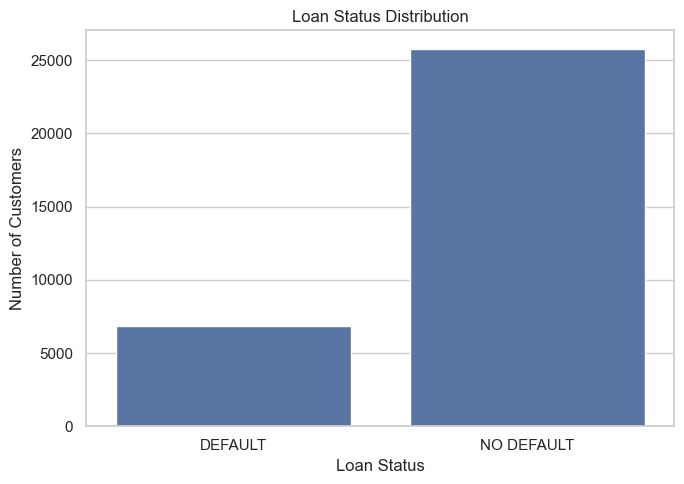

In [10]:
status_counts = df['Current_loan_status'].value_counts()
status_percent = df['Current_loan_status'].value_counts(normalize=True) * 100

distribution = pd.DataFrame({
    'Count': status_counts,
    'Percentage': status_percent.round(2)
})

display(distribution)

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x='Current_loan_status'
)

plt.title('Loan Status Distribution')
plt.xlabel('Loan Status')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

### Age Distribution Analysis

,customer_age
count,32586.000000
mean,27.732769
std,6.360528
min,3.000000
25%,23.000000
50%,26.000000
75%,30.000000
max,144.000000


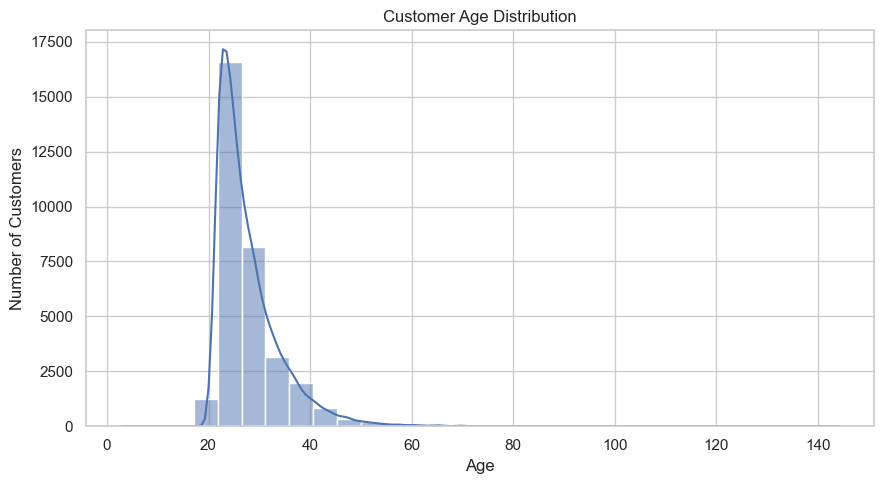

In [15]:
display(df['customer_age'].describe().to_frame())

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x='customer_age',
    bins=30,
    kde=True
)

plt.title('Customer Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()


### Credit History Analysis

,cred_hist_length
count,32586.000000
mean,5.804026
std,4.055078
min,2.000000
25%,3.000000
50%,4.000000
75%,8.000000
max,30.000000


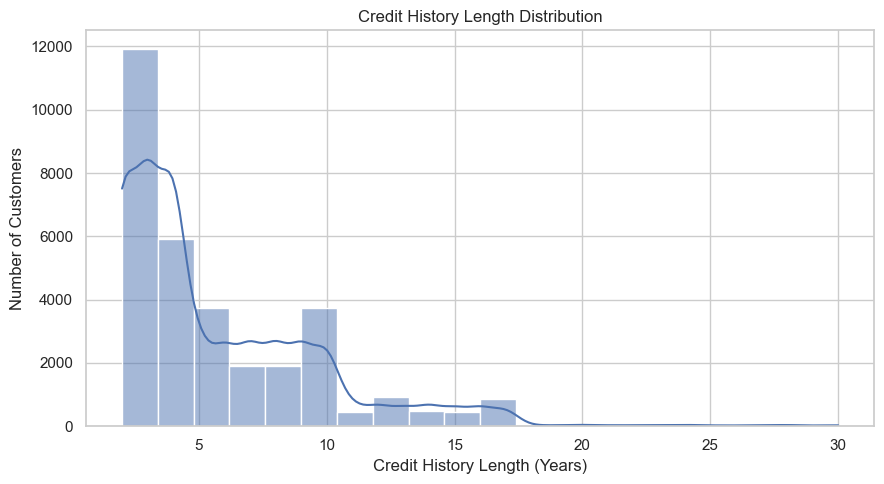

In [18]:
display(df['cred_hist_length'].describe().to_frame())

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x='cred_hist_length',
    bins=20,
    kde=True
)

plt.title('Credit History Length Distribution')
plt.xlabel('Credit History Length (Years)')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

### Historical Default Analysis

,Customer Count
historical_default,
Y,6128
N,5721


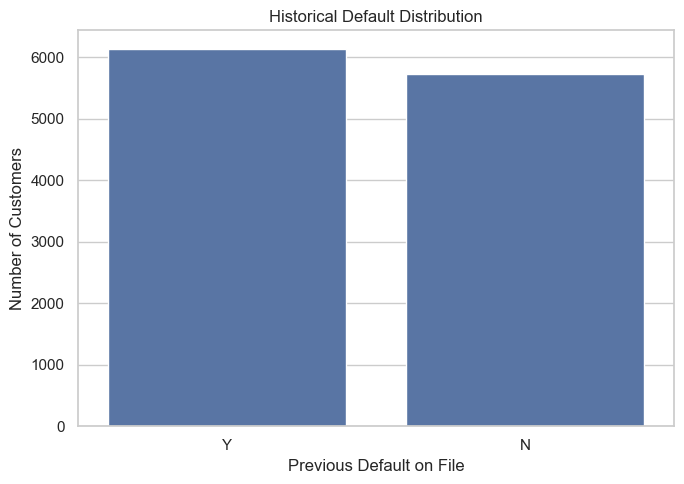

In [19]:
historical_default = df['historical_default'].value_counts()

display(historical_default.to_frame('Customer Count'))

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x='historical_default',
    order=historical_default.index
)

plt.title('Historical Default Distribution')
plt.xlabel('Previous Default on File')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

### DEFAULT RATE BY LOAN GRADE

,loan_grade,Default Rate %
0,A,10.01
1,B,19.32
2,C,35.75
3,D,58.58
4,E,72.46


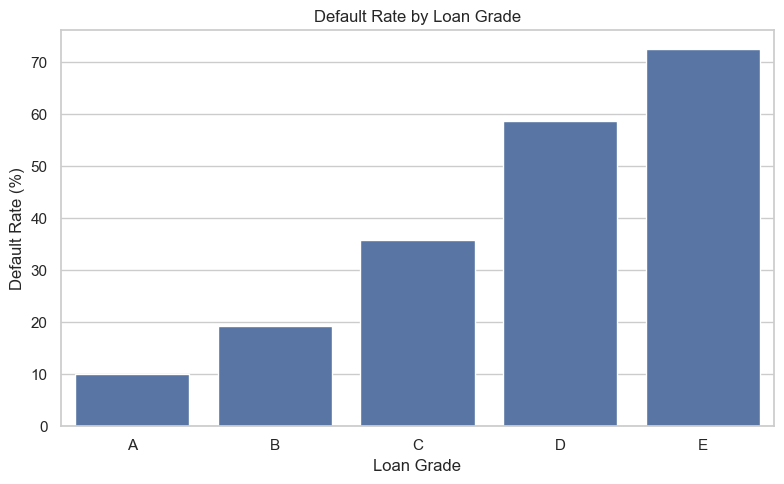

In [22]:
default_by_grade = (
    df.groupby('loan_grade')['Current_loan_status']
      .apply(lambda x: (x == 'DEFAULT').mean() * 100)
      .round(2)
      .reset_index(name='Default Rate %')
)

display(default_by_grade)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=default_by_grade,
    x='loan_grade',
    y='Default Rate %'
)

plt.title('Default Rate by Loan Grade')
plt.xlabel('Loan Grade')
plt.ylabel('Default Rate (%)')
plt.tight_layout()
plt.show()

### DEFAULT RATE BY HOME OWNERSHIP

,home_ownership,Default Rate %
0,RENT,30.96
1,OTHER,30.84
2,MORTGAGE,11.57
3,OWN,6.08


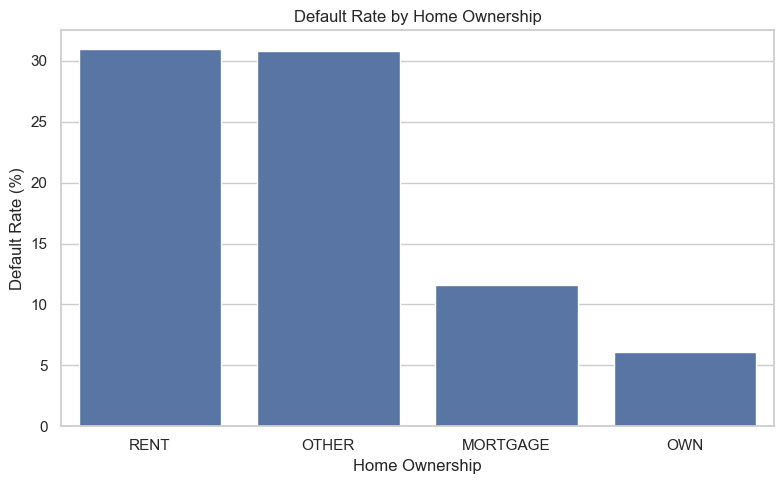

In [24]:
default_by_ownership = (
    df.groupby('home_ownership')['Current_loan_status']
      .apply(lambda x: (x == 'DEFAULT').mean() * 100)
      .round(2)
      .sort_values(ascending=False)
      .reset_index(name='Default Rate %')
)

display(default_by_ownership)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=default_by_ownership,
    x='home_ownership',
    y='Default Rate %'
)

plt.title('Default Rate by Home Ownership')
plt.xlabel('Home Ownership')
plt.ylabel('Default Rate (%)')
plt.tight_layout()
plt.show()

###  LOAN-TO-INCOME RISK ANALYSIS

In [34]:
income_numeric = pd.to_numeric(
    df['customer_income'],
    errors='coerce'
)

df['income_risk_group'] = pd.cut(
    income_numeric,
    bins=[-np.inf, 25000, 50000, 75000, 100000, np.inf],
    labels=[
        'Very Low',
        'Low',
        'Medium',
        'High',
        'Very High'
    ]
)

default_by_income = (
    df.groupby('income_risk_group', observed=True)['Current_loan_status']
      .apply(lambda x: (x == 'DEFAULT').mean() * 100)
      .round(2)
      .reset_index(name='Default Rate %')
)

display(default_by_income)

,income_risk_group,Default Rate %
0,Very Low,48.04
1,Low,26.98
2,Medium,16.97
3,High,10.73
4,Very High,9.11


### CORRELATION HEATMAP

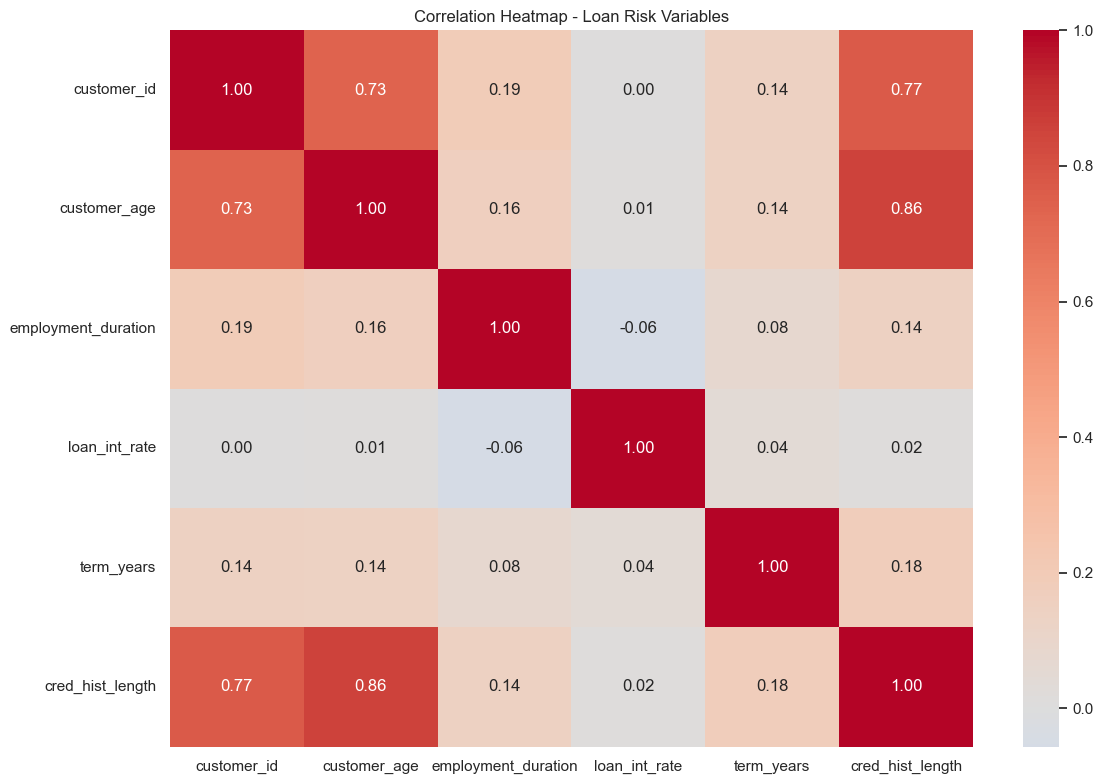

In [35]:
numeric_cols = df.select_dtypes(
    include=np.number
).columns

correlation = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Heatmap - Loan Risk Variables')
plt.tight_layout()
plt.show()

### TOP RISK COMBINATIONS

In [28]:
risk_analysis = (
    df.groupby(['loan_grade', 'loan_intent'])['Current_loan_status']
      .agg(
          Customers='count',
          Default_Rate=lambda x: (x == 'DEFAULT').mean() * 100
      )
      .reset_index()
)

risk_analysis['Default Rate %'] = (
    risk_analysis['Default_Rate']
    .round(2)
)

risk_analysis.drop(
    columns='Default_Rate',
    inplace=True
)

# Ignore combinations with very few customers
risk_analysis = risk_analysis[
    risk_analysis['Customers'] >= 50
]

risk_analysis = risk_analysis.sort_values(
    'Default Rate %',
    ascending=False
)

display(risk_analysis.head(15))

,loan_grade,loan_intent,Customers,Default Rate %
24,E,DEBTCONSOLIDATION,53,96.23
18,D,DEBTCONSOLIDATION,395,94.43
21,D,MEDICAL,479,87.27
27,E,MEDICAL,64,85.94
25,E,EDUCATION,55,63.64
12,C,DEBTCONSOLIDATION,831,50.42
29,E,VENTURE,52,50.00
20,D,HOMEIMPROVEMENT,400,47.25
15,C,MEDICAL,932,45.82
23,D,VENTURE,445,43.05


### KPI SUMMARY

In [33]:
print("\n" + "=" * 55)
print("             LOAN RISK DATASET — KPI SUMMARY")
print("=" * 55)

print(f"\nTotal Customers       : {len(df):,}")
print(f"Total Variables       : {df.shape[1]:,}")

# Default Rate
print(
    f"Overall Default Rate  : "
    f"{df['Current_loan_status'].eq('DEFAULT').mean() * 100:.2f}%"
)

# Average Loan Amount
print(
    f"Average Loan Amount   : "
    f"{pd.to_numeric(df['loan_amnt'], errors='coerce').mean():,.2f}"
)

# Average Annual Income
print(
    f"Average Annual Income : "
    f"{pd.to_numeric(df['customer_income'], errors='coerce').mean():,.2f}"
)

# Average Interest Rate
print(
    f"Average Interest Rate : "
    f"{pd.to_numeric(df['loan_int_rate'], errors='coerce').mean():.2f}%"
)

print("=" * 55)


             LOAN RISK DATASET — KPI SUMMARY

Total Customers       : 32,586
Total Variables       : 13
Overall Default Rate  : 20.99%
Average Loan Amount   : 484,926.61
Average Annual Income : 66,067.23
Average Interest Rate : 11.01%
